In [ ]:
from pathlib import Path
from datetime import datetime, date
import xarray as xr


def get_combined_ds(date: date) -> xr.Dataset:
    """
    TODO: replace with S3 access instead
    """
    base = Path("/mnt/ceph/user/dom/wekeo/test/COMBINED/")
    file = base / date.strftime("%Y_%m_%d/COMBINED_%Y-%m-%d_v1.0.nc")
    return xr.open_dataset(file)


day = date(2025, 8, 28)

ds = get_combined_ds(day)

print(ds)

<xarray.Dataset> Size: 942MB
Dimensions:                                 (latitude: 1636, longitude: 3272)
Coordinates:
  * latitude                                (latitude) float64 13kB -90.0 ......
  * longitude                               (longitude) float64 26kB -180.0 ....
Data variables: (12/44)
    s5p_pca__cloud_fraction_mean            (latitude, longitude) float32 21MB ...
    s5p_pca__score_CO_1_mean                (latitude, longitude) float32 21MB ...
    s5p_pca__score_CO_2_mean                (latitude, longitude) float32 21MB ...
    s5p_pca__score_CO_3_mean                (latitude, longitude) float32 21MB ...
    s5p_pca__diag_CO_1_mean                 (latitude, longitude) float32 21MB ...
    s5p_pca__diag_CO_2_mean                 (latitude, longitude) float32 21MB ...
    ...                                      ...
    frp_slstr__day_FRP_SWIR_no_SAA_max      (latitude, longitude) float32 21MB ...
    frp_slstr__night_FRP_SWIR_no_SAA_mean   (latitude, longitude

In [ ]:
areas = {
    "Global":          [ 90., -90.,  180., -180.],
    "North_America":   [ 90.,   9.,  -20., -169.],
    "South_America":   [  9., -60.,  -20.,  120.],
    "Europe":          [ 90.,  36.,   31.,  -20.],
    "Africa":          [ 36., -60.,   60.,  -20.],
    "Russia":          [ 90.,  36., -169.,   31.],
    "Asia":            [ 36., -10., -169.,   60.],
    "Australia":       [-10., -60., -120.,   60.],
    # "Central_Pacific": [  9., -10., -120., -169.],
    # "Antarctic":       [-60., -90.,  180., -180.],
}
    
from wekeo_combined_chain.utils import select_area

area_name = "Global"
area = areas[area_name]
    
ds_area = select_area(ds, area)

In [33]:
from wekeo_combined_chain import postprocess

ds_post, df_plumes = postprocess.compute(ds_area)

--> Active FRP cells (filtered): 2929
--> 17 plumes
--------------------------
--> Plume 1: buf_init=5  buf_final=10
** Plume 1 confirmed ** (strict=17, env=118)
   SWIR conf: none (0/2) | MWIR conf: none (0/2)
--------------------------
--------------------------
--> Plume 2: buf_init=5  buf_final=10
** Plume 2 confirmed ** (strict=0, env=29)
   SWIR conf: none (0/2) | MWIR conf: none (0/2)
--------------------------
--------------------------
--> Plume 3: buf_init=5  buf_final=9
** Plume 3 confirmed ** (strict=0, env=5)
   SWIR conf: none (0/2) | MWIR conf: none (0/2)
--------------------------
--------------------------
--> Plume 4: buf_init=11  buf_final=15
** Plume 4 confirmed ** (strict=152, env=39)
   SWIR conf: none (0/2) | MWIR conf: low (1/2)
--------------------------
--------------------------
--> Plume 5: buf_init=5  buf_final=6
** Plume 5 confirmed ** (strict=7, env=8)
   SWIR conf: none (0/2) | MWIR conf: high (2/2)
--------------------------
--------------------------
-

In [35]:
from wekeo_combined_chain.postprocess import table as T

print("Plumes:")
print("-" * 75)
print(T.plume_table(df_plumes))

print()
print("Tiny plumes:")
print("-" * 75)
print(T.tiny_plume_table(df_plumes))

Plumes:
---------------------------------------------------------------------------
   Plume label  Number of pixels  Latitude (°)  Longitude (°)
0            1               128     -7.763188      25.493009
1            2                76     -4.541284      23.446789
2            3               453     -3.516739      18.175651
3            4              3437     56.251644    -101.710673
4            5               225     61.713761    -109.661125
5            6                82     68.442157     157.968275

Tiny plumes:
---------------------------------------------------------------------------
    Plume label  Number of pixels  Latitude (°)  Longitude (°)
0           100                 1     -9.192661      22.775061
1           101                 3     41.853211      -8.215159
2           102                 2     47.559633    -123.337408
3           103                 3     59.357798    -111.821516
4           104                52     61.964714    -116.300075
5           10

In [36]:
from wekeo_combined_chain.postprocess import plot as P

date_str = day.strftime("%Y%m%d")
output_dir = Path("output") / day.strftime("%Y_%m_%d") / area_name
output_dir.mkdir(parents=True, exist_ok=True)


## Map 1 — Plumes × FRP overlay

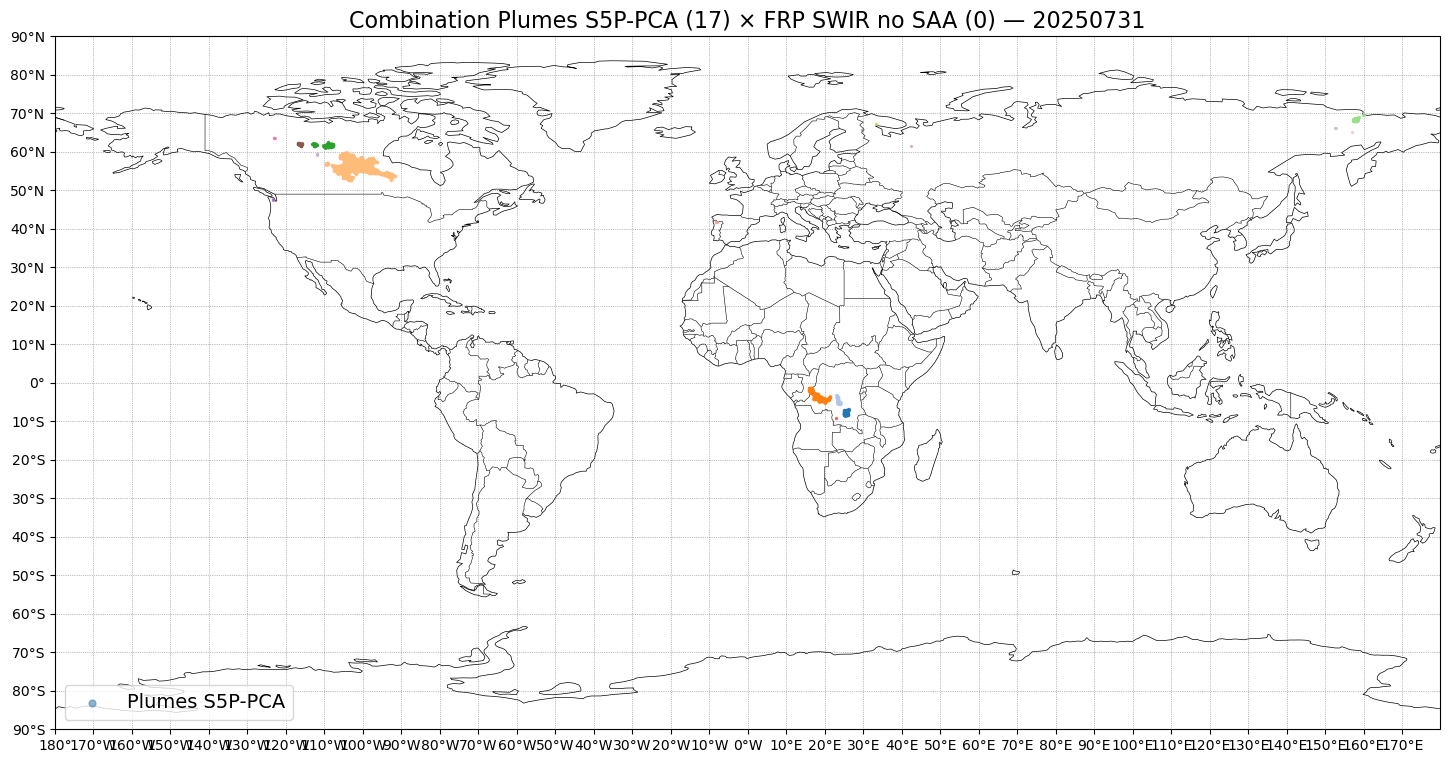

In [37]:
# Toggle save_to to write to disk, or leave None for inline display only
P.plot_plumes_frp(ds_area, ds_post, date_str, frp_channel="SWIR",
                  save_to=output_dir / f"plumes_frp_SWIR_{date_str}.png")


## Map 2 — Fire score per plume

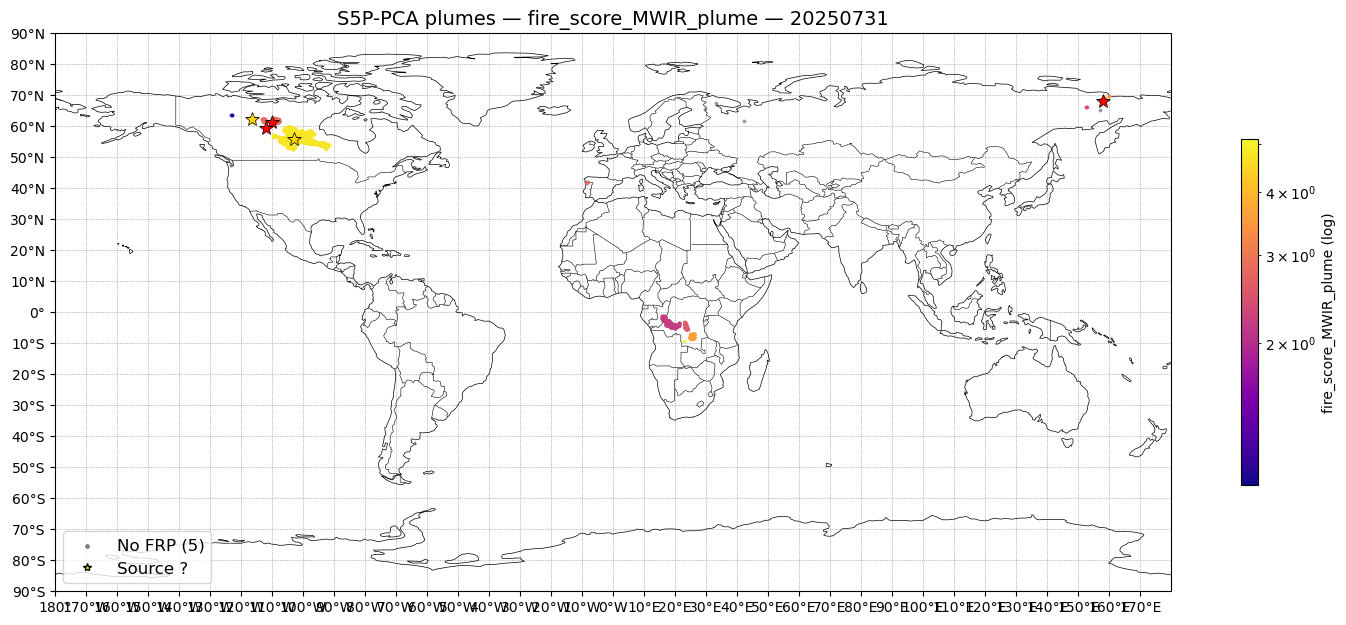

In [42]:
P.plot_fire_score_plume(ds_area, ds_post, df_plumes, date_str, band="MWIR",
                        save_to=output_dir / f"fire_score_plume_MWIR_{date_str}.png")


## Map 3 — Fire score per pixel

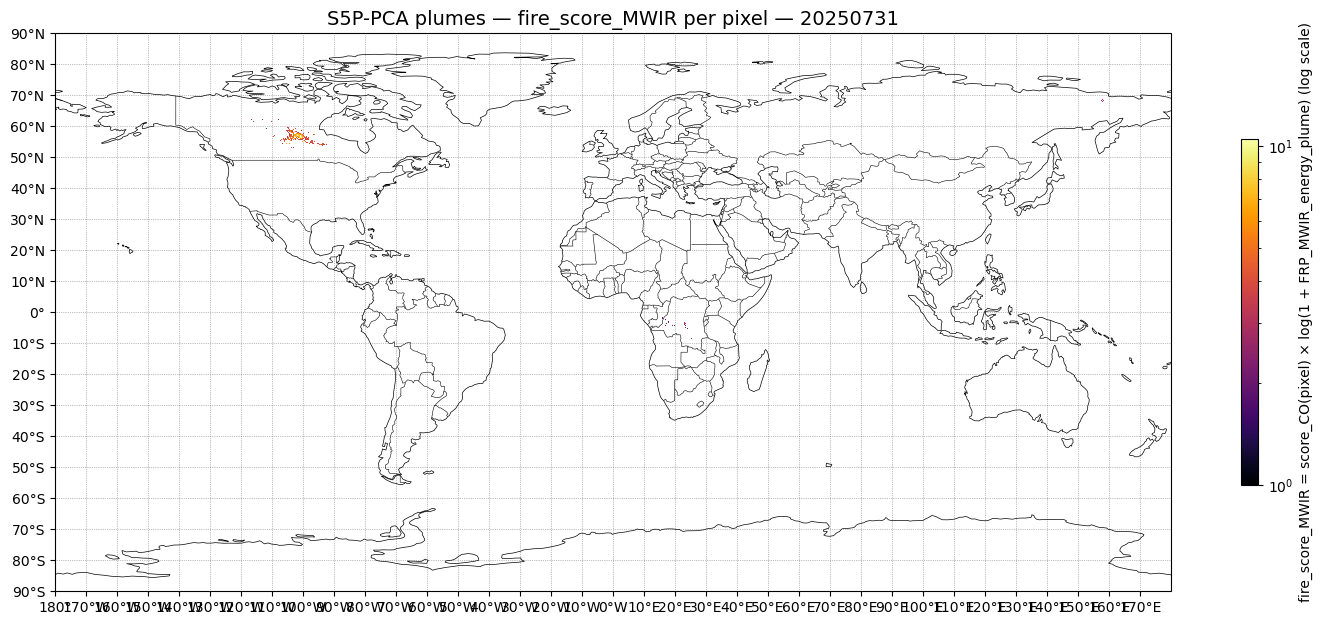

In [39]:
P.plot_fire_score_pixel(ds_area, ds_post, date_str, band="MWIR",
                        save_to=output_dir / f"fire_score_pixel_SWIR_{date_str}.png")
    

## Map 4 — Plume envelopes + source confidence

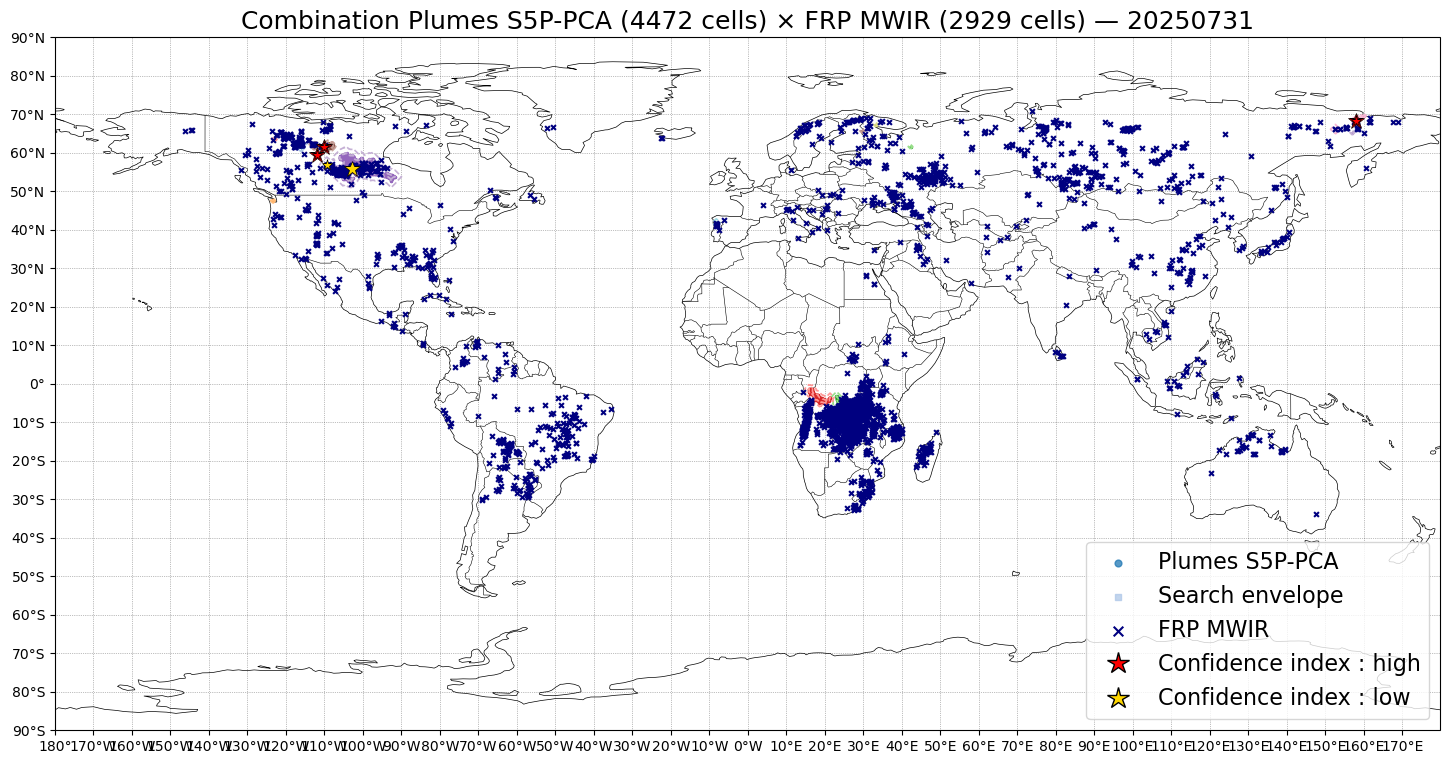

In [41]:
P.plot_plume_envelopes(ds_area, ds_post, df_plumes, date_str, frp_channel="MWIR",
                       save_to=output_dir / f"plume_envelopes_MWIR_{date_str}.png")


In [ ]:
# end of demo